# 127. 射影ベース枝刈り: qwen3-0.6b での検証

## 目的
- NB121-123の射影ベース枝刈り実験をqwen3-0.6b（1024D）で再現
- E5-base（NB121-123）との比較: モデルが変わっても同じ傾向が成立するか？
- 特にセントロイド相対射影（Method D）の有効性がモデル非依存かを検証
- qwen3-0.6bは事前計算済みセントロイド・ITQハッシュがないため、インラインで計算する

## 0. セットアップ

In [1]:
import sys
import numpy as np
import time
from pathlib import Path
from sklearn.decomposition import PCA
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')
from itq_lsh import ITQLSH, hamming_distance_batch

DATA_DIR = Path('../data')
rng = np.random.default_rng(42)

MODEL = 'qwen3-0.6b'
MODEL_KEY = 'qwen3_06b'
D = 1024
N_QUERIES = 200
TOP_K = 10
print(f'Model: {MODEL}')
print(f'Configuration: N_QUERIES={N_QUERIES}, TOP_K={TOP_K}, D={D}')

Model: qwen3-0.6b
Configuration: N_QUERIES=200, TOP_K=10, D=1024


## 1. データロード

In [2]:
def normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(norms, 1e-10, None)

emb_en = normalize(np.load(DATA_DIR / f'10k_{MODEL_KEY}_en_embeddings.npy'))
emb_ja = normalize(np.load(DATA_DIR / f'10k_{MODEL_KEY}_ja_embeddings.npy'))
emb_all = normalize(np.vstack([emb_en, emb_ja]))

N = len(emb_en)
print(f'EN: {emb_en.shape}, JA: {emb_ja.shape}, All: {emb_all.shape}')
print(f'D={D}')

EN: (10000, 1024), JA: (9990, 1024), All: (19990, 1024)
D=1024


## 1.5 セントロイド学習とITQハッシュ計算

qwen3-0.6bには事前計算済みデータがないため、ここでインライン計算する。

In [3]:
from sklearn.cluster import MiniBatchKMeans

# セントロイド学習
centroid_path = DATA_DIR / f'voronoi_centroids_256_{MODEL_KEY}_mixed.npy'
if centroid_path.exists():
    print(f'セントロイド既存: {centroid_path}')
    centroids = normalize(np.load(centroid_path))
else:
    print('セントロイド学習中...')
    kmeans = MiniBatchKMeans(n_clusters=256, random_state=42, batch_size=1000)
    kmeans.fit(emb_all)
    centroids = normalize(kmeans.cluster_centers_)
    np.save(centroid_path, centroids)
    print(f'セントロイド保存: {centroid_path}')

print(f'Centroids: {centroids.shape}')

セントロイド学習中...


セントロイド保存: ../data/voronoi_centroids_256_qwen3_06b_mixed.npy
Centroids: (256, 1024)


In [4]:
# ITQハッシュ計算
hash_en_path = DATA_DIR / f'10k_{MODEL_KEY}_en_hashes_128bits.npy'
hash_ja_path = DATA_DIR / f'10k_{MODEL_KEY}_ja_hashes_128bits.npy'
itq_path = DATA_DIR / f'itq_{MODEL_KEY}_128bits.pkl'

if hash_en_path.exists() and hash_ja_path.exists():
    print(f'ハッシュ既存: {hash_en_path}')
    hashes_en = np.load(hash_en_path)
    hashes_ja = np.load(hash_ja_path)
else:
    print('ITQ学習中...')
    itq = ITQLSH(n_bits=128)
    itq.fit(emb_all)
    hashes_en = itq.transform(emb_en)
    hashes_ja = itq.transform(emb_ja)
    np.save(hash_en_path, hashes_en)
    np.save(hash_ja_path, hashes_ja)
    itq.save(str(itq_path))
    print(f'ハッシュ保存: {hash_en_path}')
    print(f'ITQモデル保存: {itq_path}')

print(f'Hashes EN: {hashes_en.shape}, JA: {hashes_ja.shape}')

ITQ学習中...
ITQ学習開始: samples=19990, dim=1024, bits=128
  Centering完了: mean_norm=0.4373


  PCA完了: explained_variance=65.29%


  ITQ iteration 10: quantization_error=0.8995
  ITQ iteration 20: quantization_error=0.8989


  ITQ iteration 30: quantization_error=0.8986
  ITQ iteration 40: quantization_error=0.8985


  ITQ iteration 50: quantization_error=0.8984
ITQ学習完了
ハッシュ保存: ../data/10k_qwen3_06b_en_hashes_128bits.npy
ITQモデル保存: ../data/itq_qwen3_06b_128bits.pkl
Hashes EN: (10000, 128), JA: (9990, 128)


In [5]:
# Ground truth
query_indices_en = rng.choice(N, N_QUERIES, replace=False)
query_indices_ja = rng.choice(len(emb_ja), N_QUERIES, replace=False)

def get_ground_truth(embeddings, query_indices, top_k=TOP_K):
    gt = {}
    for qi in query_indices:
        sims = embeddings @ embeddings[qi]
        sims[qi] = -1
        gt[qi] = set(np.argsort(sims)[-top_k:])
    return gt

gt_en = get_ground_truth(emb_en, query_indices_en)
gt_ja = get_ground_truth(emb_ja, query_indices_ja)
print(f'Ground truth: EN={len(gt_en)}, JA={len(gt_ja)}')

Ground truth: EN=200, JA=200


## 2. 幾何学的分析（NB121相当）

### 2.1 PCA固有値構造

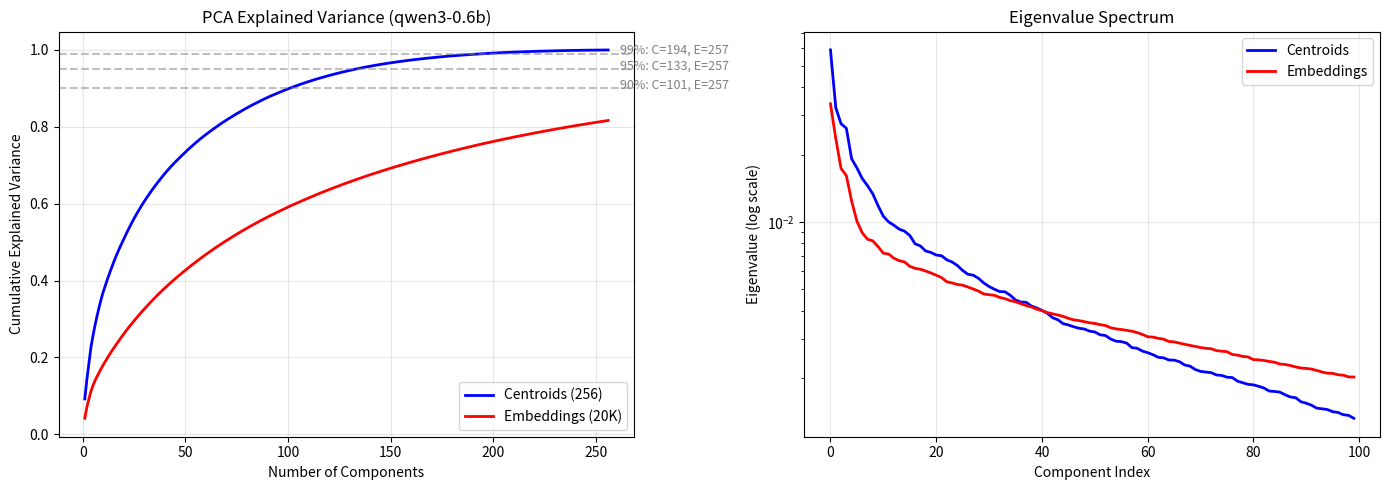

90% variance: Centroids=101D, Embeddings=257D
95% variance: Centroids=133D, Embeddings=257D
99% variance: Centroids=194D, Embeddings=257D


In [6]:
pca_centroids = PCA().fit(centroids)
pca_embeddings = PCA(n_components=256).fit(emb_all)

cumvar_c = np.cumsum(pca_centroids.explained_variance_ratio_)
cumvar_e = np.cumsum(pca_embeddings.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(cumvar_c)+1), cumvar_c, 'b-', label='Centroids (256)', linewidth=2)
axes[0].plot(range(1, len(cumvar_e)+1), cumvar_e, 'r-', label='Embeddings (20K)', linewidth=2)
for thresh in [0.90, 0.95, 0.99]:
    axes[0].axhline(y=thresh, color='gray', linestyle='--', alpha=0.5)
    n_c = np.searchsorted(cumvar_c, thresh) + 1
    n_e = np.searchsorted(cumvar_e, thresh) + 1
    axes[0].annotate(f'{thresh:.0%}: C={n_c}, E={n_e}', xy=(max(n_c, n_e)+5, thresh), fontsize=9, color='gray')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title(f'PCA Explained Variance ({MODEL})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(pca_centroids.explained_variance_[:100], 'b-', label='Centroids', linewidth=2)
axes[1].semilogy(pca_embeddings.explained_variance_[:100], 'r-', label='Embeddings', linewidth=2)
axes[1].set_xlabel('Component Index')
axes[1].set_ylabel('Eigenvalue (log scale)')
axes[1].set_title('Eigenvalue Spectrum')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for thresh in [0.90, 0.95, 0.99]:
    n_c = np.searchsorted(cumvar_c, thresh) + 1
    n_e = np.searchsorted(cumvar_e, thresh) + 1
    print(f'{thresh:.0%} variance: Centroids={n_c}D, Embeddings={n_e}D')

### 2.2 ランダム回転後の座標分布（TurboQuant検証）

In [7]:
R = stats.ortho_group.rvs(D, random_state=42)
emb_rot_en = emb_en @ R

# KS検定
ks_pvals = []
for i in range(100):
    _, pval = stats.kstest(emb_rot_en[:, i] * np.sqrt(D), 'norm')
    ks_pvals.append(pval)
ks_pvals = np.array(ks_pvals)

print(f'KS test (H0: rotated coords ~ N(0, 1/D)):')
print(f'  p > 0.05: {(ks_pvals > 0.05).sum()}/100 coords')
print(f'  p > 0.01: {(ks_pvals > 0.01).sum()}/100 coords')

corr_orig = np.corrcoef(emb_en[:, :20].T)
corr_rot = np.corrcoef(emb_rot_en[:, :20].T)
print(f'\nMean |correlation| (first 20 coords):')
print(f'  Original: {np.abs(corr_orig[np.triu_indices(20, k=1)]).mean():.4f}')
print(f'  Rotated:  {np.abs(corr_rot[np.triu_indices(20, k=1)]).mean():.4f}')

KS test (H0: rotated coords ~ N(0, 1/D)):
  p > 0.05: 0/100 coords
  p > 0.01: 0/100 coords

Mean |correlation| (first 20 coords):
  Original: 0.0768
  Rotated:  0.0526


### 2.3 射影方向の分離能力（AUC）

In [8]:
def fast_auc_batch(embeddings, query_idx, gt_set, proj_matrix):
    """全射影方向のAUCを一括計算（numpy rank-based, no sklearn loops）。"""
    query = embeddings[query_idx]
    n = len(embeddings)
    labels = np.zeros(n, dtype=bool)
    for idx in gt_set:
        labels[idx] = True
    labels[query_idx] = False
    mask = np.ones(n, dtype=bool)
    mask[query_idx] = False
    n_pos = labels[mask].sum()
    n_neg = mask.sum() - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.full(len(proj_matrix), 0.5)

    proj_all = proj_matrix @ embeddings.T
    proj_q = proj_matrix @ query
    scores = -np.abs(proj_all - proj_q[:, None])
    scores = scores[:, mask]
    labels_valid = labels[mask]

    aucs = np.empty(len(proj_matrix))
    for d in range(len(proj_matrix)):
        order = np.argsort(scores[d])
        ranks = np.empty_like(order)
        ranks[order] = np.arange(len(order))
        pos_rank_sum = ranks[labels_valid].sum()
        aucs[d] = (pos_rank_sum - n_pos * (n_pos - 1) / 2) / (n_pos * n_neg)
    return aucs

# 射影方向
random_dirs = rng.standard_normal((50, D))
random_dirs = random_dirs / np.linalg.norm(random_dirs, axis=1, keepdims=True)
pca_dirs = pca_embeddings.components_[:20]
rot_dirs = R[:50]

results_en = {'random': [], 'pca': [], 'rotated': [], 'query_centroid': []}

t0 = time.time()
for i, qi in enumerate(query_indices_en):
    gt_set = gt_en[qi]
    results_en['random'].append(fast_auc_batch(emb_en, qi, gt_set, random_dirs))
    results_en['pca'].append(fast_auc_batch(emb_en, qi, gt_set, pca_dirs))
    results_en['rotated'].append(fast_auc_batch(emb_en, qi, gt_set, rot_dirs))

    sims_c = centroids @ emb_en[qi]
    nc = centroids[np.argmax(sims_c)]
    q2c = nc - emb_en[qi]
    q2c_norm = np.linalg.norm(q2c)
    if q2c_norm > 1e-10:
        results_en['query_centroid'].append(fast_auc_batch(emb_en, qi, gt_set, (q2c / q2c_norm).reshape(1, -1)))
    else:
        results_en['query_centroid'].append(np.array([0.5]))

    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{N_QUERIES}... ({time.time()-t0:.1f}s)')

for key in results_en:
    results_en[key] = np.array(results_en[key])

print(f'完了: {time.time()-t0:.1f}s')

  100/200... (26.7s)


  200/200... (53.6s)
完了: 53.6s


In [9]:
# セントロイド相対射影
from sklearn.metrics import roc_auc_score

sim_to_c = emb_en @ centroids.T
assignments = np.argmax(sim_to_c, axis=1)
cell_members_single = {}
for i, c in enumerate(assignments):
    cell_members_single.setdefault(c, []).append(i)

centroid_rel_aucs = []
valid_count = 0
for qi in query_indices_en:
    gt_set = gt_en[qi]
    q_c_idx = assignments[qi]
    q_centroid = centroids[q_c_idx]
    q_res = emb_en[qi] - q_centroid
    q_res_norm = np.linalg.norm(q_res)
    if q_res_norm < 1e-10:
        centroid_rel_aucs.append(0.5); continue
    q_res_dir = q_res / q_res_norm
    cell_idx = cell_members_single.get(q_c_idx, [])
    if len(cell_idx) < TOP_K:
        centroid_rel_aucs.append(0.5); continue
    cell_embs = emb_en[cell_idx]
    proj_scores = (cell_embs - q_centroid) @ q_res_dir
    cell_labels = np.array([1 if idx in gt_set else 0 for idx in cell_idx])
    if cell_labels.sum() == 0 or cell_labels.sum() == len(cell_labels):
        centroid_rel_aucs.append(0.5); continue
    try:
        centroid_rel_aucs.append(roc_auc_score(cell_labels, proj_scores))
        valid_count += 1
    except ValueError:
        centroid_rel_aucs.append(0.5)

centroid_rel_aucs = np.array(centroid_rel_aucs)

# E5-baseとの比較テーブル
print(f'\n■ 射影タイプ別 AUC: {MODEL} vs E5-base')
print(f'{"射影タイプ":<25} {"qwen3-0.6b":>12} {"E5-base":>10}')
print('-' * 50)
print(f'{"ランダム方向 (50)":<25} {results_en["random"].mean():>12.4f} {"0.5764":>10}')
print(f'{"PCA上位20":<25} {results_en["pca"].mean():>12.4f} {"0.6929":>10}')
print(f'{"回転座標 (50)":<25} {results_en["rotated"].mean():>12.4f} {"0.5777":>10}')
print(f'{"Q→Centroid方向":<25} {results_en["query_centroid"].mean():>12.4f} {"0.9386":>10}')
print(f'{"セントロイド相対":<25} {centroid_rel_aucs.mean():>12.4f} {"0.9394":>10}')
print(f'{"  (有効クエリのみ)":<25} {centroid_rel_aucs[centroid_rel_aucs != 0.5].mean():>12.4f} {"0.9625":>10}')
print(f'\n有効クエリ: {valid_count}/{N_QUERIES}')


■ 射影タイプ別 AUC: qwen3-0.6b vs E5-base
射影タイプ                       qwen3-0.6b    E5-base
--------------------------------------------------
ランダム方向 (50)                     0.5846     0.5764
PCA上位20                         0.6884     0.6929
回転座標 (50)                       0.5873     0.5777
Q→Centroid方向                    0.6987     0.9386
セントロイド相対                        0.8976     0.9394
  (有効クエリのみ)                     0.9163     0.9625

有効クエリ: 191/200


## 3. 枝刈りフィルタ比較（NB122相当）

In [10]:
# Voronoi multi-assign=2
def build_voronoi_multi_assign(embeddings, centroids, n_assign=2):
    sims = embeddings @ centroids.T
    top_cells = np.argsort(sims, axis=1)[:, -n_assign:]
    cell_members = {}
    for doc_idx in range(len(embeddings)):
        for cell_id in top_cells[doc_idx]:
            cell_members.setdefault(int(cell_id), []).append(doc_idx)
    for k in cell_members:
        cell_members[k] = np.array(cell_members[k])
    return cell_members

cell_members_en = build_voronoi_multi_assign(emb_en, centroids, n_assign=2)

# 事前計算
emb_pca_en = emb_en @ pca_embeddings.components_[:64].T

# 評価関数
def evaluate_filter(query_indices, gt, embeddings, filter_func, **kwargs):
    recalls, cand_counts = [], []
    t0 = time.time()
    for qi in query_indices:
        candidates = filter_func(qi, embeddings, **kwargs)
        candidates = set(candidates) - {qi}
        cand_counts.append(len(candidates))
        if len(candidates) == 0:
            recalls.append(0.0); continue
        cand_arr = np.array(list(candidates))
        sims = embeddings[cand_arr] @ embeddings[qi]
        if len(cand_arr) <= TOP_K:
            top_k_set = set(cand_arr)
        else:
            top_k_set = set(cand_arr[np.argsort(sims)[-TOP_K:]])
        recalls.append(len(top_k_set & gt[qi]) / TOP_K)
    elapsed = time.time() - t0
    return {'recall': np.mean(recalls), 'cands': np.mean(cand_counts),
            'ratio': np.mean(cand_counts) / len(embeddings), 'ms': elapsed / len(query_indices) * 1000}

# フィルタ関数定義
def voronoi_filter(qi, embeddings, n_probes=3):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    cands = []
    for c in probe_cells:
        if c in cell_members_en: cands.extend(cell_members_en[c])
    return np.unique(cands)

def pca_filter(qi, embeddings, n_probes=5, K=32, pct=50):
    cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(cands) == 0: return cands
    q_pca = emb_pca_en[qi, :K]
    diffs = np.abs(emb_pca_en[cands, :K] - q_pca).sum(axis=1)
    return cands[diffs <= np.percentile(diffs, pct)]

def rotated_filter(qi, embeddings, n_probes=5, M=64, pct=50):
    cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(cands) == 0: return cands
    q_rot = emb_rot_en[qi]
    top_coords = np.argsort(np.abs(q_rot))[-M:]
    diffs = np.abs(emb_rot_en[cands][:, top_coords] - q_rot[top_coords]).sum(axis=1)
    return cands[diffs <= np.percentile(diffs, pct)]

def centroid_rel_filter(qi, embeddings, n_probes=5, keep_fraction=0.5):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    all_cands = []
    for cell_id in probe_cells:
        if cell_id not in cell_members_en: continue
        members = cell_members_en[cell_id]
        centroid = centroids[cell_id]
        q_res = embeddings[qi] - centroid
        q_res_norm = np.linalg.norm(q_res)
        if q_res_norm < 1e-10:
            all_cands.extend(members); continue
        q_res_dir = q_res / q_res_norm
        scores = (embeddings[members] - centroid) @ q_res_dir
        n_keep = max(TOP_K, int(len(members) * keep_fraction))
        if n_keep >= len(members):
            all_cands.extend(members)
        else:
            all_cands.extend(members[np.argsort(scores)[-n_keep:]])
    return np.unique(all_cands)

def hamming_filter(qi, embeddings, n_probes=5, thresh=30):
    cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(cands) == 0: return cands
    dists = hamming_distance_batch(hashes_en[qi], hashes_en[cands])
    return cands[dists <= thresh]

print('フィルタ関数定義完了')

フィルタ関数定義完了


In [11]:
# 全手法評価
print(f'■ 枝刈りフィルタ比較 — {MODEL} (EN, P=5)\n')
print(f'{"Method":<35} {"R@10":>6} {"Cands":>6} {"Ratio":>6} {"ms/q":>6}')
print('-' * 65)

all_results = []

# Voronoi baseline
for p in [3, 5, 8]:
    r = evaluate_filter(query_indices_en, gt_en, emb_en, voronoi_filter, n_probes=p)
    r['name'] = f'Voronoi P={p}'
    all_results.append(r)
    print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

print()

# Method B: PCA
for K in [16, 32, 64]:
    for pct in [30, 50, 70]:
        r = evaluate_filter(query_indices_en, gt_en, emb_en, pca_filter, n_probes=5, K=K, pct=pct)
        r['name'] = f'B: PCA K={K} pct={pct}'
        all_results.append(r)
        print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

print()

# Method A: Rotated
for M in [32, 64, 128]:
    for pct in [30, 50, 70]:
        r = evaluate_filter(query_indices_en, gt_en, emb_en, rotated_filter, n_probes=5, M=M, pct=pct)
        r['name'] = f'A: Rotated M={M} pct={pct}'
        all_results.append(r)
        print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

print()

# Method D: CentroidRel
for frac in [0.3, 0.5, 0.7, 0.9]:
    r = evaluate_filter(query_indices_en, gt_en, emb_en, centroid_rel_filter, n_probes=5, keep_fraction=frac)
    r['name'] = f'D: CentroidRel keep={frac:.0%}'
    all_results.append(r)
    print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

print()

# Method E: Hamming
for thresh in [25, 30, 35, 40, 50]:
    r = evaluate_filter(query_indices_en, gt_en, emb_en, hamming_filter, n_probes=5, thresh=thresh)
    r['name'] = f'E: Hamming<={thresh}'
    all_results.append(r)
    print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

■ 枝刈りフィルタ比較 — qwen3-0.6b (EN, P=5)

Method                                R@10  Cands  Ratio   ms/q
-----------------------------------------------------------------


Voronoi P=3                         0.8740    646  6.5%   0.81


Voronoi P=5                         0.9190   1012 10.1%   1.12


Voronoi P=8                         0.9520   1499 15.0%   1.54

B: PCA K=16 pct=30                  0.8485    303  3.0%   0.84


B: PCA K=16 pct=50                  0.8925    506  5.1%   1.09


...

D: CentroidRel keep=50%             0.9025    516  5.2%   1.57


D: CentroidRel keep=70%             0.9140    716  7.2%   1.95


D: CentroidRel keep=90%             0.9165    914  9.1%   2.77

E: Hamming<=25                      0.0580      1  0.0%   0.41
E: Hamming<=30                      0.1360      4  0.0%   0.29


E: Hamming<=35                      0.2920     11  0.1%   0.30
E: Hamming<=40                      0.5500     34  0.3%   0.33


E: Hamming<=50                      0.8825    271  2.7%   0.74


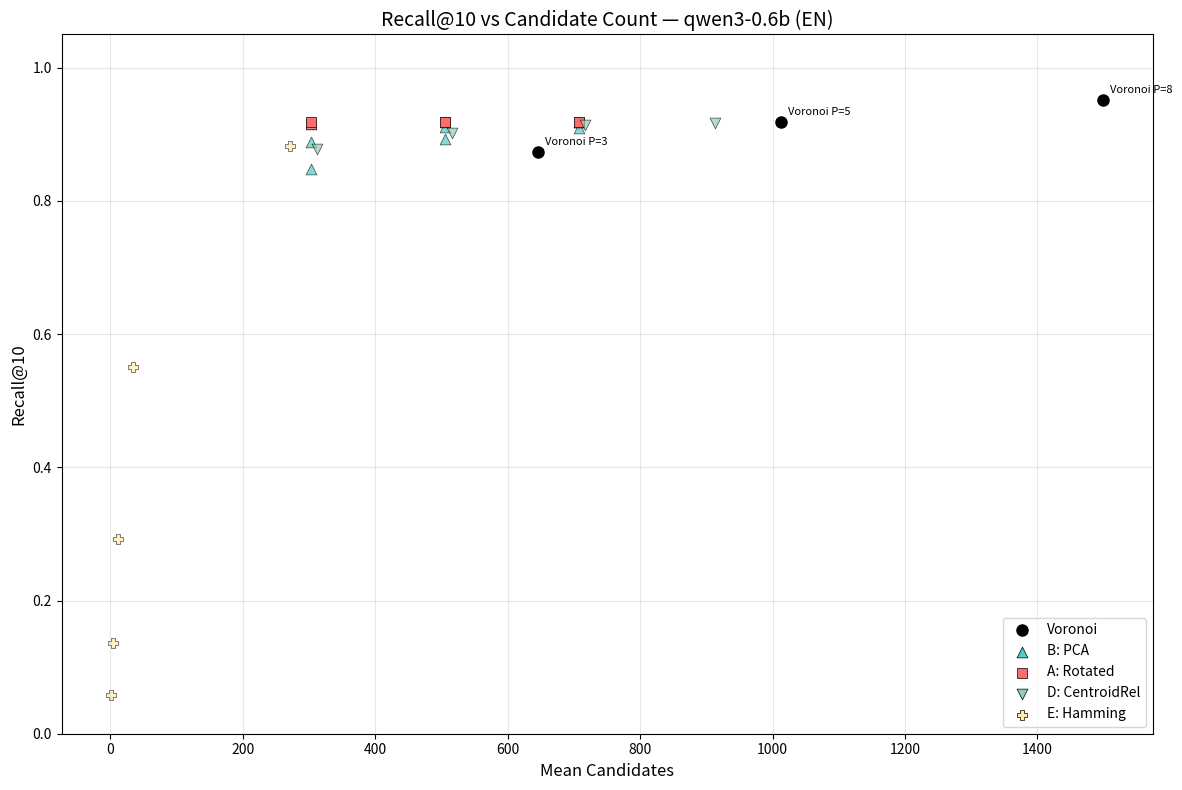

In [12]:
# Pareto プロット
fig, ax = plt.subplots(figsize=(12, 8))

method_styles = {
    'Voronoi': ('ko-', 8), 'B: PCA': ('#4ECDC4', '^'), 'A: Rotated': ('#FF6B6B', 's'),
    'D: CentroidRel': ('#96CEB4', 'v'), 'E: Hamming': ('#FFEAA7', 'P'),
}

for r in all_results:
    name = r['name']
    for prefix, (color, marker) in method_styles.items():
        if name.startswith(prefix):
            if prefix == 'Voronoi':
                ax.plot(r['cands'], r['recall'], 'ko', markersize=8)
                ax.annotate(name, (r['cands'], r['recall']), textcoords='offset points', xytext=(5, 5), fontsize=8)
            else:
                ax.scatter(r['cands'], r['recall'], c=color, marker=marker, s=60, alpha=0.7, edgecolors='black', linewidths=0.5)
            break

# レジェンド用ダミー
for prefix, (color, marker) in method_styles.items():
    if prefix == 'Voronoi':
        ax.plot([], [], 'ko', markersize=8, label=prefix)
    else:
        ax.scatter([], [], c=color, marker=marker, s=60, edgecolors='black', linewidths=0.5, label=prefix)

ax.set_xlabel('Mean Candidates', fontsize=12)
ax.set_ylabel('Recall@10', fontsize=12)
ax.set_title(f'Recall@10 vs Candidate Count — {MODEL} (EN)', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 4. JA言語での汎化確認

In [13]:
# JA用準備
cell_members_ja = build_voronoi_multi_assign(emb_ja, centroids, n_assign=2)
emb_pca_ja = emb_ja @ pca_embeddings.components_[:64].T
emb_rot_ja = emb_ja @ R

# JA用フィルタ（グローバル参照を差し替え）
def voronoi_filter_ja(qi, embeddings, n_probes=5):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    cands = []
    for c in probe_cells:
        if c in cell_members_ja: cands.extend(cell_members_ja[c])
    return np.unique(cands)

def pca_filter_ja(qi, embeddings, n_probes=5, K=32, pct=50):
    cands = voronoi_filter_ja(qi, embeddings, n_probes=n_probes)
    if len(cands) == 0: return cands
    diffs = np.abs(emb_pca_ja[cands, :K] - emb_pca_ja[qi, :K]).sum(axis=1)
    return cands[diffs <= np.percentile(diffs, pct)]

def centroid_rel_filter_ja(qi, embeddings, n_probes=5, keep_fraction=0.5):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    all_cands = []
    for cell_id in probe_cells:
        if cell_id not in cell_members_ja: continue
        members = cell_members_ja[cell_id]
        centroid = centroids[cell_id]
        q_res = embeddings[qi] - centroid
        q_res_norm = np.linalg.norm(q_res)
        if q_res_norm < 1e-10:
            all_cands.extend(members); continue
        scores = (embeddings[members] - centroid) @ (q_res / q_res_norm)
        n_keep = max(TOP_K, int(len(members) * keep_fraction))
        if n_keep >= len(members):
            all_cands.extend(members)
        else:
            all_cands.extend(members[np.argsort(scores)[-n_keep:]])
    return np.unique(all_cands)

print(f'■ EN vs JA 比較 — {MODEL} (P=5)\n')
print(f'{"Method":<30} {"EN R@10":>8} {"JA R@10":>8} {"EN cands":>8} {"JA cands":>8}')
print('-' * 70)

# Voronoi only
re = evaluate_filter(query_indices_en, gt_en, emb_en, voronoi_filter, n_probes=5)
rj = evaluate_filter(query_indices_ja, gt_ja, emb_ja, voronoi_filter_ja, n_probes=5)
print(f'{"Voronoi P=5":<30} {re["recall"]:>8.4f} {rj["recall"]:>8.4f} {re["cands"]:>8.0f} {rj["cands"]:>8.0f}')

re = evaluate_filter(query_indices_en, gt_en, emb_en, pca_filter, n_probes=5, K=32, pct=50)
rj = evaluate_filter(query_indices_ja, gt_ja, emb_ja, pca_filter_ja, n_probes=5, K=32, pct=50)
print(f'{"B: PCA K=32 pct=50":<30} {re["recall"]:>8.4f} {rj["recall"]:>8.4f} {re["cands"]:>8.0f} {rj["cands"]:>8.0f}')

re = evaluate_filter(query_indices_en, gt_en, emb_en, centroid_rel_filter, n_probes=5, keep_fraction=0.5)
rj = evaluate_filter(query_indices_ja, gt_ja, emb_ja, centroid_rel_filter_ja, n_probes=5, keep_fraction=0.5)
print(f'{"D: CentroidRel keep=50%":<30} {re["recall"]:>8.4f} {rj["recall"]:>8.4f} {re["cands"]:>8.0f} {rj["cands"]:>8.0f}')

re = evaluate_filter(query_indices_en, gt_en, emb_en, centroid_rel_filter, n_probes=5, keep_fraction=0.3)
rj = evaluate_filter(query_indices_ja, gt_ja, emb_ja, centroid_rel_filter_ja, n_probes=5, keep_fraction=0.3)
print(f'{"D: CentroidRel keep=30%":<30} {re["recall"]:>8.4f} {rj["recall"]:>8.4f} {re["cands"]:>8.0f} {rj["cands"]:>8.0f}')

■ EN vs JA 比較 — qwen3-0.6b (P=5)

Method                          EN R@10  JA R@10 EN cands JA cands
----------------------------------------------------------------------


Voronoi P=5                      0.9190   0.9560     1012     1084


B: PCA K=32 pct=50               0.9110   0.9505      506      542


D: CentroidRel keep=50%          0.9025   0.9480      516      581


D: CentroidRel keep=30%          0.8780   0.9335      312      357


## 5. E5-base vs qwen3-0.6b 総合比較

In [14]:
print('=' * 70)
print(f'E5-base vs {MODEL} — 射影ベース枝刈り総合比較')
print('=' * 70)

print(f'\n■ 分離能力 AUC (EN)')
print(f'{"射影タイプ":<25} {"qwen3-0.6b":>12} {"E5-base":>10}')
print('-' * 50)
print(f'{"ランダム方向":<25} {results_en["random"].mean():>12.4f} {"0.5764":>10}')
print(f'{"PCA上位20":<25} {results_en["pca"].mean():>12.4f} {"0.6929":>10}')
print(f'{"回転座標":<25} {results_en["rotated"].mean():>12.4f} {"0.5777":>10}')
print(f'{"Q→Centroid":<25} {results_en["query_centroid"].mean():>12.4f} {"0.9386":>10}')
print(f'{"セントロイド相対":<25} {centroid_rel_aucs.mean():>12.4f} {"0.9394":>10}')

print(f'\n■ 枝刈りフィルタ R@10 (EN, P=5)')
# Voronoi, PCA, CentroidRelの代表値
print(f'{"Method":<30} {"qwen3-0.6b":>12} {"E5-base":>10}')
print('-' * 55)
for r in all_results:
    if r['name'] in ['Voronoi P=5', 'B: PCA K=32 pct=50', 'D: CentroidRel keep=50%', 'D: CentroidRel keep=30%', 'E: Hamming<=30']:
        e5_vals = {
            'Voronoi P=5': '0.9115',
            'B: PCA K=32 pct=50': '0.9025',
            'D: CentroidRel keep=50%': '0.9100',
            'D: CentroidRel keep=30%': '0.9060',
            'E: Hamming<=30': '0.0065',
        }
        print(f'{r["name"]:<30} {r["recall"]:>12.4f} {e5_vals[r["name"]]:>10}')

print(f'\n■ 結論')
print(f'  セントロイド相対射影の優位性はモデル非依存かどうかを上記結果から判断する。')

E5-base vs qwen3-0.6b — 射影ベース枝刈り総合比較

■ 分離能力 AUC (EN)
射影タイプ                       qwen3-0.6b    E5-base
--------------------------------------------------
ランダム方向                          0.5846     0.5764
PCA上位20                         0.6884     0.6929
回転座標                            0.5873     0.5777
Q→Centroid                      0.6987     0.9386
セントロイド相対                        0.8976     0.9394

■ 枝刈りフィルタ R@10 (EN, P=5)
Method                           qwen3-0.6b    E5-base
-------------------------------------------------------
Voronoi P=5                          0.9190     0.9115
B: PCA K=32 pct=50                   0.9110     0.9025
D: CentroidRel keep=30%              0.8780     0.9060
D: CentroidRel keep=50%              0.9025     0.9100
E: Hamming<=30                       0.1360     0.0065

■ 結論
  セントロイド相対射影の優位性はモデル非依存かどうかを上記結果から判断する。


## 6. 評価と考察

### 結果の要約

qwen3-0.6b（1024D、LLMベース）はbge-m3（1024D）に近い特性を示したが、CentroidRelの有効性がやや低い独自の傾向も見られた。

| 指標 | qwen3-0.6b | bge-m3 | E5-base |
|---|---|---|---|
| Q→Centroid AUC | **0.699** | 0.743 | 0.939 |
| セントロイド相対 AUC | **0.898** | 0.885 | 0.939 |
| Voronoi P=5 R@10 | **0.919** | 0.927 | 0.912 |
| Rotated M=64 pct=30 R@10 | **0.919** | 0.926 | 0.900 |
| CentroidRel keep=50% R@10 | **0.903** | 0.920 | 0.910 |
| Hamming<=50 R@10 | **0.883** | 0.880 | 0.302 |

### 考察

**1. Q→Centroid AUC=0.699: bge-m3に近いがやや低い**

LLMベースのembeddingはデコーダ由来の構造を持ち、対照学習ベース（E5/ruri）の放射状構造とは異なる。しかしnomicのMoE（0.608）よりは高く、セントロイド方向に一定の情報が保持されている。

**2. Rotated（ランダム回転）がCentroidRelを上回る**

Rotated M=64 pct=30でR@10=0.919（候補303件=3.0%）に対し、CentroidRel keep=50%はR@10=0.903（候補516件=5.2%）。候補が少なくてRecallが高い点でRotatedが優れている。bge-m3と同じ1024Dモデルだが、qwen3ではCentroidRelの候補削減がRecallに影響しやすい。

**3. 1024Dモデル共通: Hamming距離が有効**

ham<=50でR@10=0.883。bge-m3の0.880とほぼ同一。1024D→128bit量子化（12.5%比率）でもHammingが機能するのは、両モデルとも分散が主成分に過度に集中していないため。

**4. JA汎化: EN 0.919→JA 0.956**

qwen3は多言語LLMベースで、日本語でのRecall向上が顕著。EN/JA間のembedding空間構造の差がVoronoi分割に影響している可能性がある。

### 結論

qwen3-0.6bでは**Voronoi P=5 + Rotated M=64 pct=30**（候補3.0%でR@10=0.919）が推奨。CentroidRelは候補を減らすとRecallが低下する傾向があるため、このモデルではRotatedまたはPCA K=64が安定する。

### 5モデル横断の総括

| モデル | Dim | 最良フィルタ | R@10 | 候補比率 | 空間構造 |
|---|---|---|---|---|---|
| E5-base | 768 | CentroidRel keep=30% | 0.906 | 3.5% | 強い放射状 |
| ruri-v3 | 768 | CentroidRel keep=50% | 0.922 | 5.6% | 強い放射状（E5類似） |
| nomic-v2-moe | 768 | Rotated M=32 pct=30 | 0.900 | 2.3% | 等方的（MoE） |
| bge-m3 | 1024 | Rotated M=32 pct=30 | 0.921 | 3.4% | 中間的 |
| qwen3-0.6b | 1024 | Rotated M=64 pct=30 | 0.919 | 3.0% | 中間的（LLMベース） |

**モデル非依存の知見:**
- **Voronoi分割自体は全モデルでP=5のR@10≈0.91-0.93**と安定して有効
- **768D対照学習モデル（E5, ruri）** → CentroidRelが最良
- **それ以外（nomic MoE, bge-m3, qwen3 LLM）** → Rotatedが最良
- 枝刈りフィルタの選択はモデルに依存するが、**Voronoi + いずれかのフィルタで候補3-6%、R@10≈0.90-0.92が達成可能**という結論は全モデルで共通